<a href="https://colab.research.google.com/github/Krisha314/Laptop_Price_Prediction/blob/main/Laptop_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To handle warnings:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# All required models and libraries to train and test the dataset :
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
# Load Dataset:
df=pd.read_csv("laptop_price - dataset.csv")
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [4]:
# Inspect basic Structure of the dataset:
print("Dataset Shape:",df.shape)
print("\nData Types & Info:")
print(df.info())

Dataset Shape: (1275, 15)

Data Types & Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float

In [5]:
# Handling missing value:
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates Rows Count:", df.duplicated().sum())


Missing Values:
Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

Duplicates Rows Count: 0


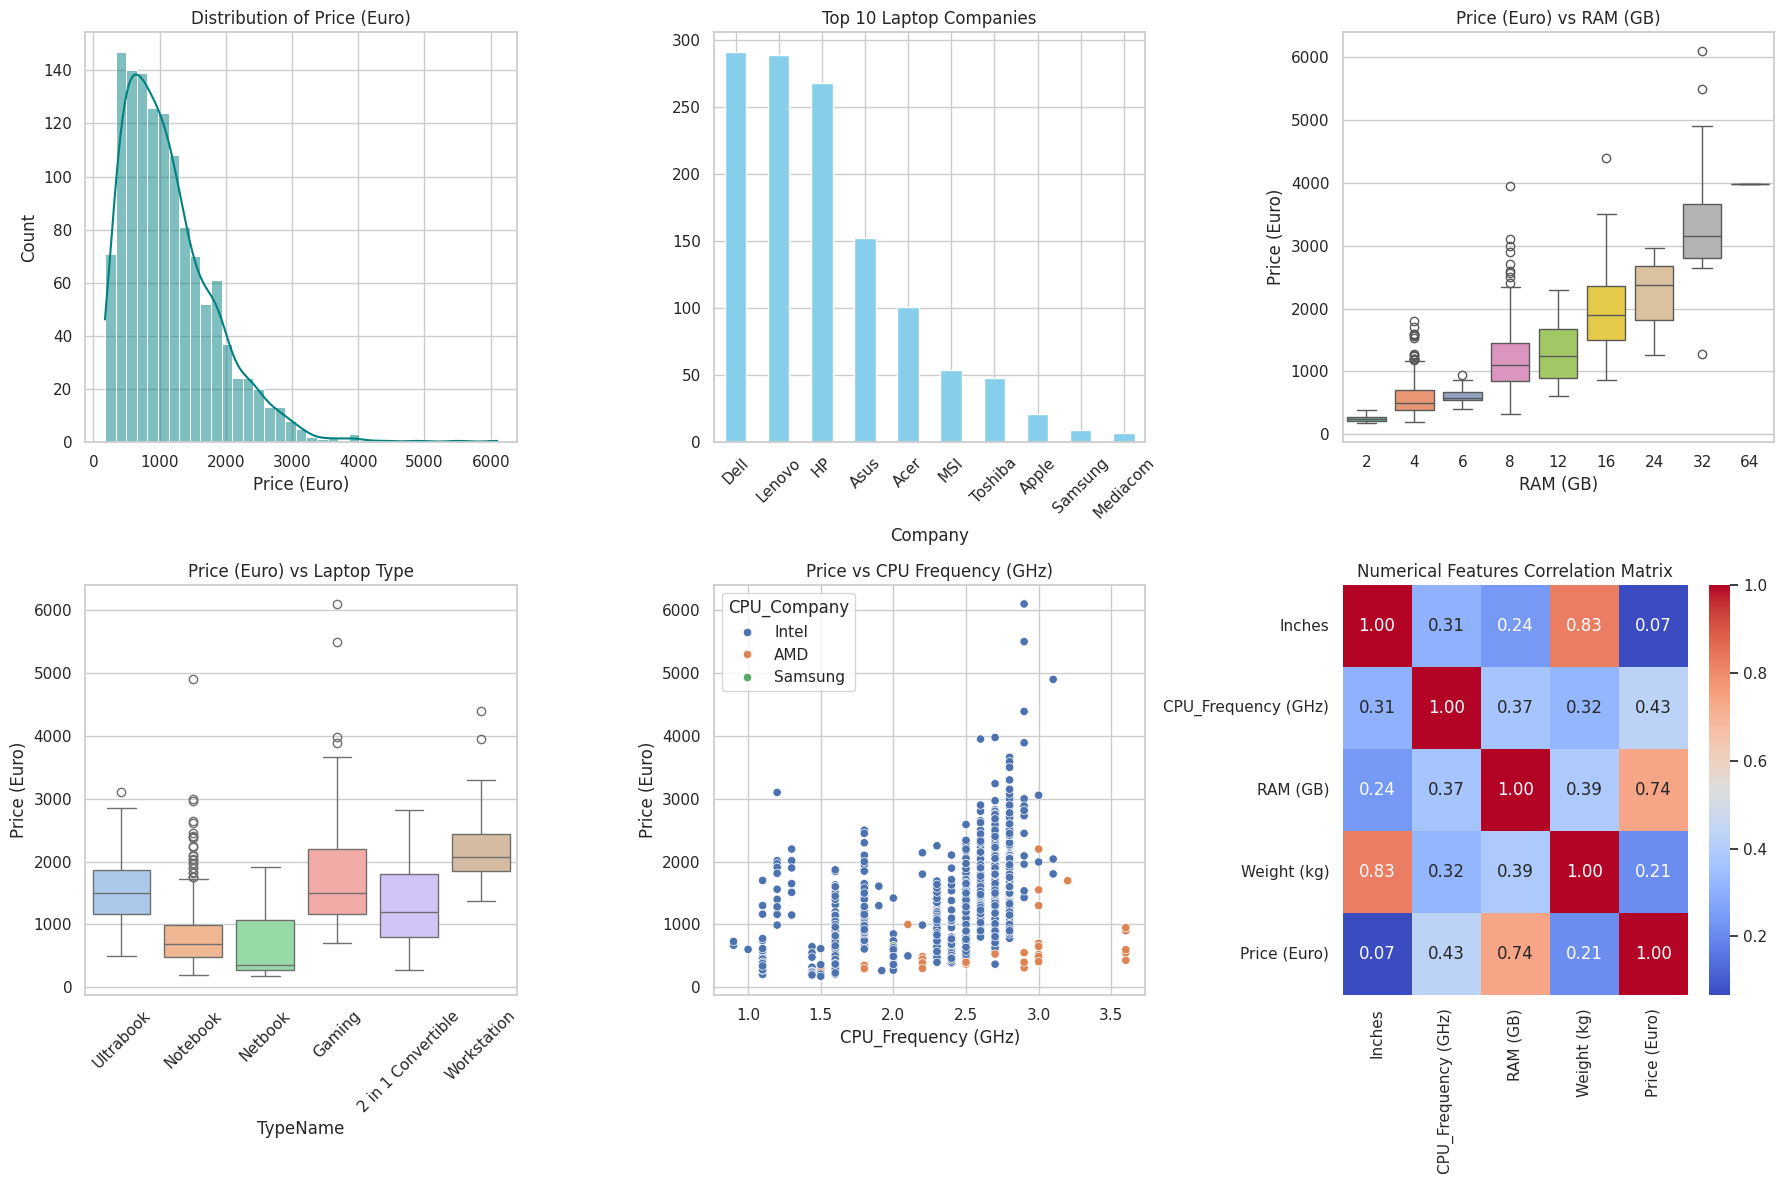

In [7]:
# Set visualization style:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

# 1. Target Distribution (Univariate):
plt.subplot(2, 3, 1)
sns.histplot(df['Price (Euro)'], kde=True, color='teal')
plt.title('Distribution of Price (Euro)')

# 2. Categorical Analysis: Company (Univariate):
plt.subplot(2, 3, 2)
df['Company'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Laptop Companies')
plt.xticks(rotation=45)

# 3. Bivariate: Price vs RAM:
plt.subplot(2, 3, 3)
sns.boxplot(x='RAM (GB)', y='Price (Euro)', data=df, palette='Set2')
plt.title('Price (Euro) vs RAM (GB)')

# 4. Bivariate: Price vs TypeName:
plt.subplot(2, 3, 4)
sns.boxplot(x='TypeName', y='Price (Euro)', data=df, palette='pastel')
plt.title('Price (Euro) vs Laptop Type')
plt.xticks(rotation=45)

# 5. Bivariate: Price vs CPU_Frequency (GHz):
plt.subplot(2, 3, 5)
sns.scatterplot(x='CPU_Frequency (GHz)', y='Price (Euro)', hue='CPU_Company', data=df)
plt.title('Price vs CPU Frequency (GHz)')

# 6. Multivariate Correlation Heatmap:
plt.subplot(2, 3, 6)
num_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numerical Features Correlation Matrix')

plt.tight_layout()
plt.show()

In [8]:
# 1. Drop exact duplicates:
df = df.drop_duplicates()

# 2. Impute missing values (if any exist):
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Feature Engineering from 'Memory' column:
# Extract SSD and HDD storage amounts in GB:
def extract_storage(text, drive_type):
    text = str(text).upper()
    if drive_type in text:
        parts = text.split('+') if '+' in text else [text]
        for part in parts:
            if drive_type in part:
                num = part.replace(drive_type, '').replace('GB', '').replace('TB', '000').strip()
                try:
                    return float(num)
                except ValueError:
                    return 0.0
    return 0.0

df['SSD_GB'] = df['Memory'].apply(lambda x: extract_storage(x, 'SSD'))
df['HDD_GB'] = df['Memory'].apply(lambda x: extract_storage(x, 'HDD'))

# 4. Handle Outliers (IQR Capping on Target):
Q1 = df['Price (Euro)'].quantile(0.25)
Q3 = df['Price (Euro)'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
df['Price (Euro)'] = np.clip(df['Price (Euro)'], lower_limit, upper_limit)

# 5. Drop high-cardinality / raw columns not needed directly:
df_clean = df.drop(columns=['Product', 'Memory', 'ScreenResolution'])

In [10]:
# Separate Features and Target:
X = df_clean.drop(columns=['Price (Euro)'])
y = df_clean['Price (Euro)']

# Updated numeric_features list  exact column name:
numeric_features = ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)', 'SSD_GB', 'HDD_GB']
categorical_features = ['Company', 'TypeName', 'CPU_Company', 'CPU_Type', 'GPU_Company', 'GPU_Type', 'OpSys']

# Construct Preprocessing ColumnTransformer:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 80/20 Train-Test Split:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Model': name,
        'R² Score': round(r2, 4),
        'MAE (Euro)': round(mae, 2),
        'RMSE (Euro)': round(rmse, 2)
    })

comparison_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False)
display(comparison_df)

,Model,R² Score,MAE (Euro),RMSE (Euro)
2,Random Forest,0.8519,171.45,239.84
3,Gradient Boosting,0.8512,180.92,240.44
0,Linear Regression,0.7933,213.07,283.34
1,Decision Tree,0.7786,200.52,293.28


In [12]:
# Tune Random Forest Regressor:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# Final Evaluation:
y_final_pred = best_model.predict(X_test)
print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Final Test R² Score: {r2_score(y_test, y_final_pred):.4f}")
print(f"Final Test RMSE: {np.sqrt(mean_squared_error(y_test, y_final_pred)):.2f} Euro")

Optimal Hyperparameters: {'regressor__max_depth': 20, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Final Test R² Score: 0.8511
Final Test RMSE: 240.51 Euro


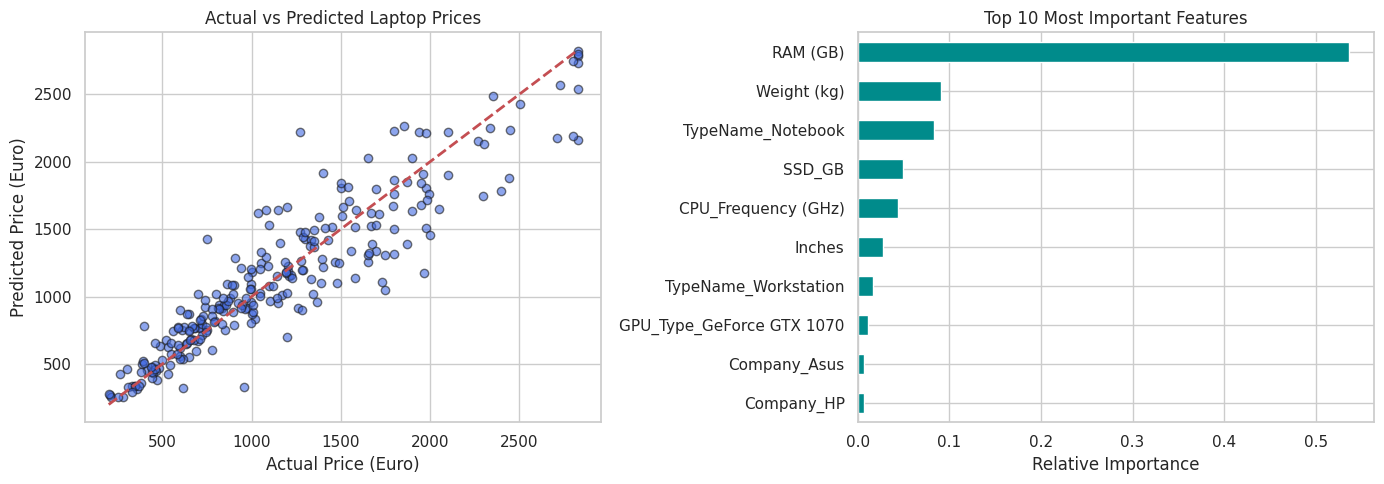

In [13]:
# 1. Actual vs Predicted Plot:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_final_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Laptop Prices')
plt.xlabel('Actual Price (Euro)')
plt.ylabel('Predicted Price (Euro)')

# 2. Extract Top 10 Feature Importances:
rf_model = best_model.named_steps['regressor']
encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_encoded_cols = encoder.get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_encoded_cols)

importances = pd.Series(rf_model.feature_importances_, index=all_features)
top_10 = importances.sort_values(ascending=False).head(10)

plt.subplot(1, 2, 2)
top_10.plot(kind='barh', color='darkcyan').invert_yaxis()
plt.title('Top 10 Most Important Features')
plt.xlabel('Relative Importance')

plt.tight_layout()
plt.show()

### Submission Summary & Key Findings
- Model Selected: Random Forest Regressor optimized via 5-Fold Cross-Validation (n_estimators=200, max_depth=20, min_samples_split=2)
- Goodness of Fit ($R^2$): 0.8511 — The model captures 85.11% of the total variance in laptop market pricing.
- Error Metrics: Test RMSE is €240.51, indicating average prediction error remains contained relative to wide laptop price ranges.- Key Drivers: High-impact predictors consistently include RAM (GB), CPU frequency/type, SSD storage capacity, and premium GPU configurations.
